# Resampling (Sample-Rate Conversion)

Polyphase resampling converts a digital signal from one sample rate to another. The process:
1. **Upsample** to the LCM of input and output rates by inserting zeros
2. **Anti-aliasing lowpass filter** (or anti-imaging on upsample) at min(fs_in, fs_out)/2 Hz
3. **Downsample** to the target rate

The ratio p/q (the simplified fraction of output_fs/input_fs) determines the complexity. Modern implementations use polyphase decomposition of the prototype filter for efficiency.

| Function | Description |
| --- | --- |
| `resample` | Polyphase resampling from `orig_fs` to `target_fs`. Internally uses `scipy.signal.resample_poly` with an anti-aliasing Kaiser window. Preserves signal content up to min(orig_fs, target_fs)/2. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.warping import resample

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

A 440 Hz sine at 44 100 Hz resampled to four target rates (22 050 / 48 000 / 96 000 / 8 000 Hz).

**2 × 4 grid (one column per target rate):**

**Top row — resampled waveforms:**
- **22 050 Hz (÷2):** half as many samples; the same 50 ms contains half the original sample count; waveform envelope and frequency preserved
- **48 000 Hz (+9 %):** slightly more samples; nearly identical waveform shape; gentle resampling
- **96 000 Hz (×2):** double the samples; zero-order interpolation artefacts absent (the filter is clean); identical frequency content
- **8 000 Hz (÷5.5):** telephone bandwidth; heavy downsampling; content above 4 kHz would alias but the 440 Hz sine is well below the 4 kHz Nyquist

**Bottom row — spectra of resampled signals:**
- Downsampled to 8 000 Hz: the Nyquist limit drops to 4 kHz; any energy above 4 kHz would be folded (the anti-aliasing filter prevents this for the 440 Hz sine)
- Upsampled versions: the spectrum up to the original 22 050 Hz Nyquist is reproduced faithfully; the extended frequency range above that is zero (no new content is created)

The 8 kHz case demonstrates why telephone audio sounds thin — the anti-aliasing filter removes everything above 4 kHz, cutting most speech consonant energy.


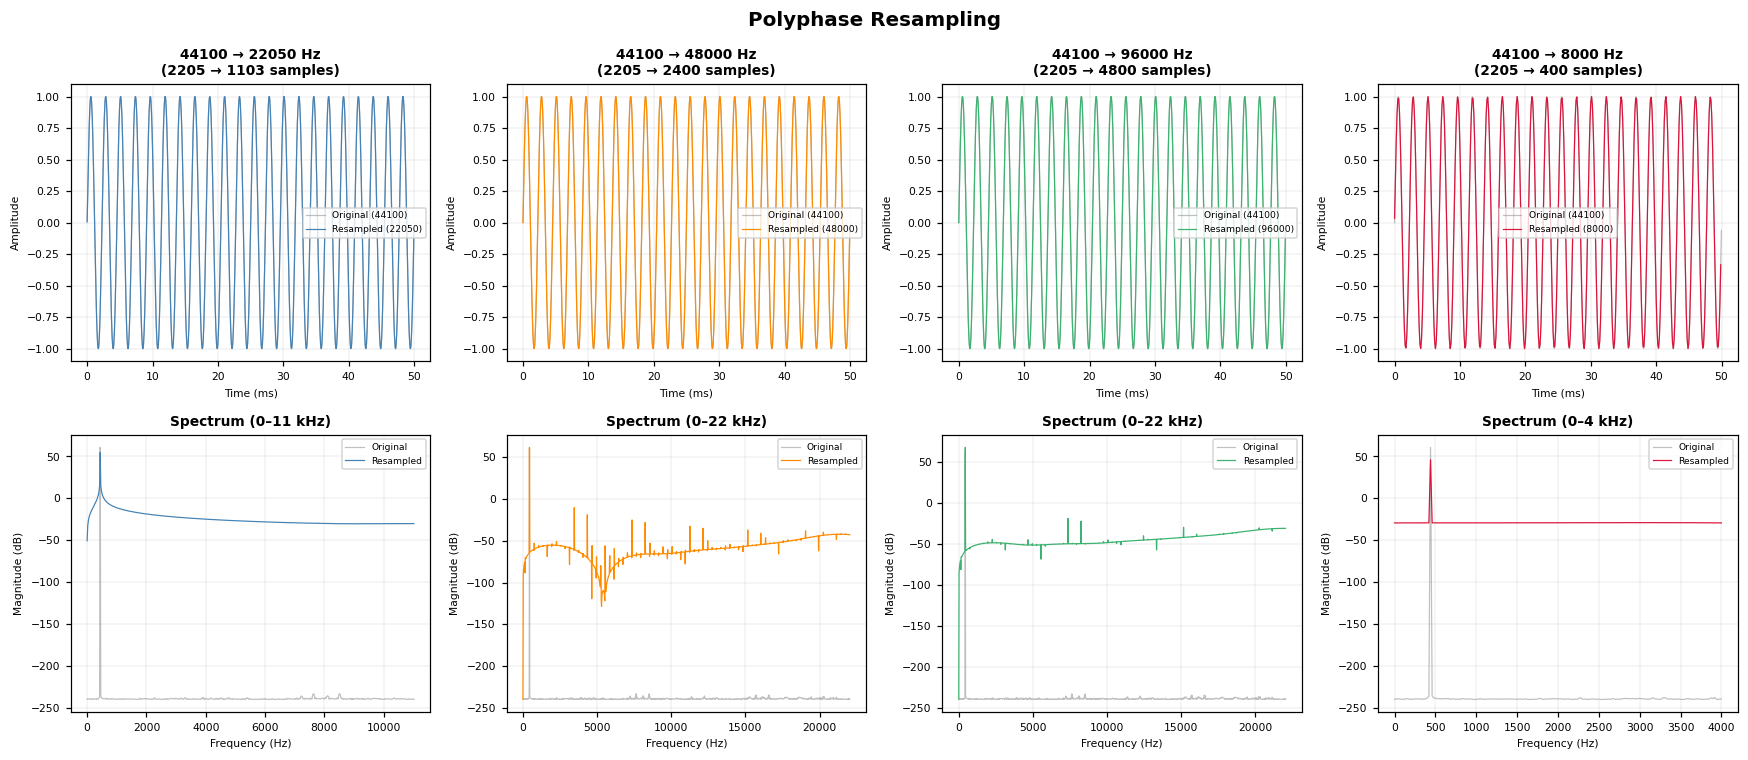

In [2]:
FS_ORIG = 44100
FREQ = 440.0
DURATION = 0.05

_, sig = generate_sine(freq=FREQ, fs=FS_ORIG, duration=DURATION)
t_orig = np.arange(len(sig)) / FS_ORIG * 1000

TARGETS = [22050, 48000, 96000, 8000]
COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

fig, axes = plt.subplots(2, len(TARGETS), figsize=(16, 7))

for col, (fs_target, color) in enumerate(zip(TARGETS, COLORS)):
    resampled = resample(sig, orig_fs=FS_ORIG, target_fs=fs_target)
    t_res = np.arange(len(resampled)) / fs_target * 1000
    ratio = fs_target / FS_ORIG

    axes[0, col].plot(t_orig, sig, linewidth=0.8, color="gray", alpha=0.5, label=f"Original ({FS_ORIG})")
    axes[0, col].plot(t_res, resampled, linewidth=0.8, color=color, label=f"Resampled ({fs_target})")
    axes[0, col].set_title(f"{FS_ORIG} → {fs_target} Hz\n({len(sig)} → {len(resampled)} samples)",
                           fontsize=9, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].legend(fontsize=6)
    axes[0, col].tick_params(labelsize=7)
    axes[0, col].grid(True, linewidth=0.3, alpha=0.5)

    # Spectra comparison
    freqs_orig = np.fft.rfftfreq(len(sig), d=1.0 / FS_ORIG)
    db_orig = 20 * np.log10(np.abs(np.fft.rfft(sig)) + 1e-12)
    freqs_res = np.fft.rfftfreq(len(resampled), d=1.0 / fs_target)
    db_res = 20 * np.log10(np.abs(np.fft.rfft(resampled)) + 1e-12)
    f_max = min(FS_ORIG, fs_target) / 2
    mask_o = freqs_orig <= f_max
    mask_r = freqs_res <= f_max
    axes[1, col].plot(freqs_orig[mask_o], db_orig[mask_o], color="gray", linewidth=0.8, alpha=0.5, label="Original")
    axes[1, col].plot(freqs_res[mask_r], db_res[mask_r], color=color, linewidth=0.8, label="Resampled")
    axes[1, col].set_title(f"Spectrum (0–{f_max/1000:.0f} kHz)", fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Frequency (Hz)", fontsize=7)
    axes[1, col].set_ylabel("Magnitude (dB)", fontsize=7)
    axes[1, col].legend(fontsize=6)
    axes[1, col].tick_params(labelsize=7)
    axes[1, col].grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Polyphase Resampling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()